# Higgs Boson Discovery Analysis
ATLAS Open Data - 13 TeV Proton-Proton Collisions

# Libraries for data loading, numerial conutation, and visualization

In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# Data Loading and Event Selection

Loading four data files from the ATLAS Open Data 13 TeV dataset, containing real proton-proton collision events. For each event we apply:

- **Tight photon ID**: both photons must pass ATLAS quality criteria
- **pt/mass ratio cuts**: leading photon pt > 35% of diphoton mass, subleading > 25%
- **Eta acceptance**: photons within detector acceptance, excluding the crack region (1.37 < |eta| < 1.52)

In [2]:
# file loading
# tight photon selection
# 4-vector extraction
# invariant mass calculation
# pt and eta cuts

files = ['data_A.GamGam.root', 'data_B.GamGam.root', 
         'data_C.GamGam.root', 'data_D.GamGam.root']

all_masses = []

for filename in files:
    f = uproot.open(filename)
    tree = f['mini;1']
    
    arrays = tree.arrays(
        ['photon_pt', 'photon_eta', 'photon_phi', 'photon_E', 'photon_isTightID'],
        library='ak'
    )
    
    # Select events with exactly 2 photons, both passing tight ID
    n_photons = ak.num(arrays['photon_pt'], axis=1)
    tight = arrays['photon_isTightID']
    n_tight = ak.sum(tight, axis=1)
    mask = (n_photons == 2) & (n_tight == 2)
    selected = arrays[mask]
    
    # Extract 4-vector components and convert MeV to GeV
    E = ak.to_numpy(ak.flatten(selected['photon_E'])).reshape(-1, 2) / 1000
    eta = ak.to_numpy(ak.flatten(selected['photon_eta'])).reshape(-1, 2)
    phi = ak.to_numpy(ak.flatten(selected['photon_phi'])).reshape(-1, 2)
    pt = ak.to_numpy(ak.flatten(selected['photon_pt'])).reshape(-1, 2) / 1000
    
    E1, E2 = E[:, 0], E[:, 1]
    eta1, eta2 = eta[:, 0], eta[:, 1]
    phi1, phi2 = phi[:, 0], phi[:, 1]
    pt1 = pt[:, 0].flatten()
    pt2 = pt[:, 1].flatten()
    
    # Compute preliminary invariant mass
    mass_prelim = np.sqrt(2 * E1 * E2 * (np.cosh(eta1 - eta2) - np.cos(phi1 - phi2)))
    
    # Apply standard ATLAS diphoton selection cuts
    pt1_cut = pt1 / mass_prelim > 0.35
    pt2_cut = pt2 / mass_prelim > 0.25
    eta1_cut = (np.abs(eta1) < 2.37) & ~((np.abs(eta1) > 1.37) & (np.abs(eta1) < 1.52))
    eta2_cut = (np.abs(eta2) < 2.37) & ~((np.abs(eta2) > 1.37) & (np.abs(eta2) < 1.52))
    
    all_cuts = pt1_cut & pt2_cut & eta1_cut & eta2_cut
    mass_final = mass_prelim[all_cuts]
    
    all_masses.append(mass_final)
    print(f"{filename}: {len(mass_final)} events")

mass_all = np.concatenate(all_masses)
print(f"\nTotal events: {len(mass_all)}")

data_A.GamGam.root: 22722 events
data_B.GamGam.root: 80970 events
data_C.GamGam.root: 118311 events
data_D.GamGam.root: 190996 events

Total events: 412999


# Invariant Mass Spectrum and Higgs Signal Extraction

Plotting the diphoton invariant mass distribution and using the sideband method to model and subtract the background. The Higgs boson signal can be seen at 125 GeV.

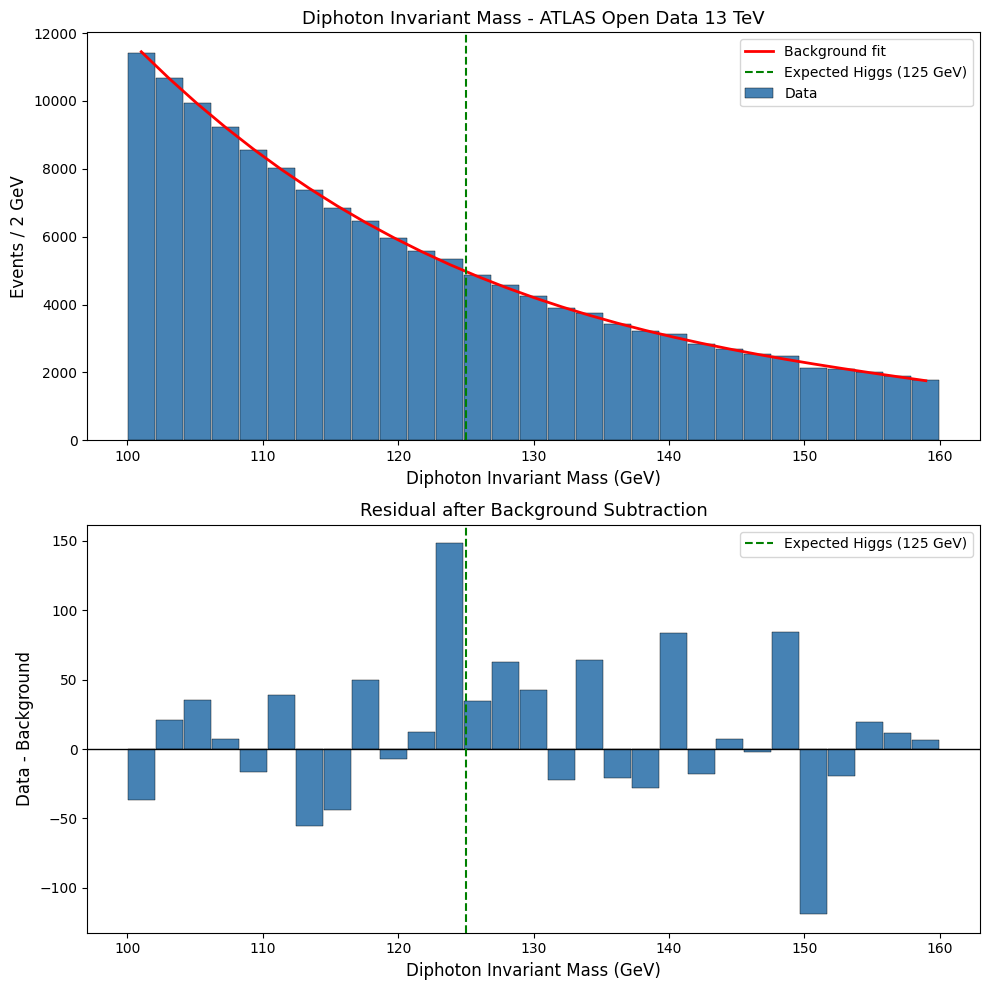

In [3]:
# Plotting Cell

# Filter to Higgs mass window
mask = (mass_all > 100) & (mass_all < 160)
mass_window = mass_all[mask]

# Create histogram with 2 GeV bins
bins = np.linspace(100, 160, 30)
counts, bin_edges = np.histogram(mass_window, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit polynomial to sideband regions (away from Higgs signal)
sideband = (bin_centers < 115) | (bin_centers > 135)
coeffs = np.polyfit(bin_centers[sideband], counts[sideband], 4)
background = np.polyval(coeffs, bin_centers)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Top: data with background fit
ax1.bar(bin_centers, counts, width=2.0, color='steelblue',
        edgecolor='black', linewidth=0.3, label='Data')
ax1.plot(bin_centers, background, 'r-', linewidth=2, label='Background fit')
ax1.axvline(x=125, color='green', linestyle='--', label='Expected Higgs (125 GeV)')
ax1.set_xlabel('Diphoton Invariant Mass (GeV)', fontsize=12)
ax1.set_ylabel('Events / 2 GeV', fontsize=12)
ax1.set_title('Diphoton Invariant Mass - ATLAS Open Data 13 TeV', fontsize=13)
ax1.legend()

# Bottom: residual after background subtraction
residual = counts - background
ax2.bar(bin_centers, residual, width=2.0, color='steelblue',
        edgecolor='black', linewidth=0.3)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.axvline(x=125, color='green', linestyle='--', label='Expected Higgs (125 GeV)')
ax2.set_xlabel('Diphoton Invariant Mass (GeV)', fontsize=12)
ax2.set_ylabel('Data - Background', fontsize=12)
ax2.set_title('Residual after Background Subtraction', fontsize=13)
ax2.legend()

plt.tight_layout()
plt.savefig('higgs_discovery.png', dpi=150)
plt.show()

# Mass Measurement
Fitting a Gaussian to the signal region of the residual to extract a precise measurement of the Higgs mass.

In [4]:
from scipy.optimize import curve_fit

# Define a Gaussian function
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# Fit Gaussian to the residual in the signal region
signal_region = (bin_centers > 115) & (bin_centers < 135)
x_signal = bin_centers[signal_region]
y_signal = residual[signal_region]

# Initial parameter guesses: amplitude, mean, sigma
p0 = [150, 125, 2]

popt, pcov = curve_fit(gaussian, x_signal, y_signal, p0=p0)
perr = np.sqrt(np.diag(pcov))

amplitude, mean, sigma = popt
amp_err, mean_err, sigma_err = perr

print(f"Fitted Higgs mass: {mean:.2f} +/- {mean_err:.2f} GeV")
print(f"Width (sigma): {sigma:.2f} +/- {sigma_err:.2f} GeV")
print(f"Amplitude: {amplitude:.1f} +/- {amp_err:.1f} events")

Fitted Higgs mass: 124.06 +/- 0.83 GeV
Width (sigma): 1.05 +/- 0.52 GeV
Amplitude: 152.8 +/- 57.6 events


# Result

Our measured Higgs mass of 124.06 +/- 0.83 GeV is consistent with the known value of 1254.09 GeV, within the statistical uncertainty.

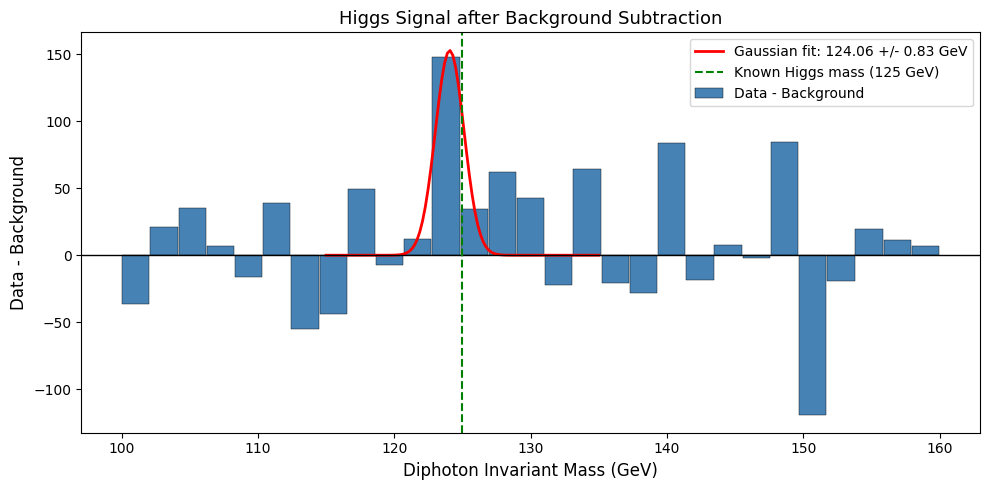

In [5]:
# Plot residual with Gaussian fit overlaid
x_fit = np.linspace(115, 135, 100)
y_fit = gaussian(x_fit, amplitude, mean, sigma)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bin_centers, residual, width=2.0, color='steelblue',
       edgecolor='black', linewidth=0.3, label='Data - Background')
ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
        label=f'Gaussian fit: {mean:.2f} +/- {mean_err:.2f} GeV')
ax.axhline(y=0, color='black', linewidth=1)
ax.axvline(x=125, color='green', linestyle='--', label='Known Higgs mass (125 GeV)')
ax.set_xlabel('Diphoton Invariant Mass (GeV)', fontsize=12)
ax.set_ylabel('Data - Background', fontsize=12)
ax.set_title('Higgs Signal after Background Subtraction', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('higgs_signal.png', dpi=150)
plt.show()